In [18]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import Sequential,layers

In [16]:
df = np.load("/content/organcmnist.npz")

In [17]:
df.keys()

KeysView(NpzFile '/content/organcmnist.npz' with keys: train_images, train_labels, val_images, val_labels, test_images...)

Text(0.5, 1.0, '[6]')

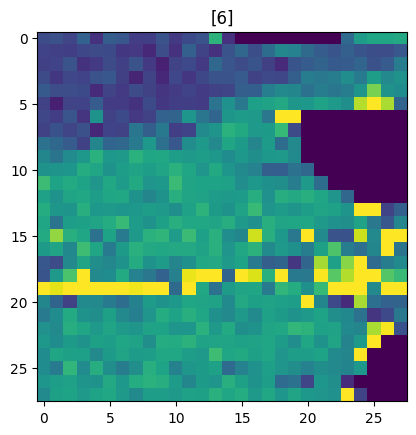

In [23]:
#lets see how the pictures looks

import matplotlib.pyplot as plt

plt.imshow(df["train_images"][2])
plt.title(df["train_labels"][2])

# i have checked it, it shows a stomach

In [24]:
x_train,y_train = df["train_images"],df["train_labels"]

x_test,y_test = df["test_images"],df["test_labels"]

x_val,y_val = df["val_images"], df["val_labels"]

In [39]:
x_train = x_train.astype("float")/255.0
x_test = x_test.astype("float")/255.0
x_val = x_val.astype("float")/255.0

In [51]:
from tensorflow.keras import Sequential, layers
from tensorflow.keras.layers import Input

model = Sequential()
model.add(Input(shape=(28, 28))) # Add the Input layer here

In [93]:
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.layers import Dropout

model.add(Flatten()) # Remove input_shape here
model.add(Dense(128, activation = "relu"))
model.add(Dropout(0.2))
model.add(Dense(64, activation = "relu"))
model.add(Dropout(0.2))
model.add(Dense(11, activation = "softmax"))

In [94]:
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 11)             │         1,419 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 11)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 11)             │           715 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 11)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 128)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 11)             │           715 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 747,855 (2.85 MB)

 Trainable params: 256,289 (1001.13 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 491,566 (1.88 MB)

In [95]:
model.compile(optimizer = "adam", loss = "sparse_categorical_crossentropy", metrics = ["accuracy"])

In [96]:
from tensorflow.keras.callbacks import EarlyStopping

callback = EarlyStopping(

                         monitor = "val_loss",
                         min_delta = 0.00001,
                         patience = 10,
                         verbose = 1,
                         mode = "auto",
                         restore_best_weights = False

)

In [101]:
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomContrast(0.1),
])

In [113]:
history = model.fit(x_train,y_train, validation_data = (x_val,y_val), epochs = 50, batch_size = 256, verbose = 1)

Epoch 1/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.2953 - loss: 2.0601 - val_accuracy: 0.8127 - val_loss: 0.9704
Epoch 2/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.8168 - loss: 0.7368 - val_accuracy: 0.8675 - val_loss: 0.6316
Epoch 3/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8520 - loss: 0.5489 - val_accuracy: 0.8591 - val_loss: 0.6435
Epoch 4/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8732 - loss: 0.4599 - val_accuracy: 0.8809 - val_loss: 0.5796
Epoch 5/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8927 - loss: 0.3927 - val_accuracy: 0.8842 - val_loss: 0.5287
Epoch 6/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8928 - loss: 0.3874 - val_accuracy: 0.8909 - val_loss: 0.5556
Epoch 7/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8971 - loss: 0.3552 - val_accuracy: 0.8976 - val_loss: 0.4854
Epoch 8/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9136 - loss: 0.3116 - val_accuracy: 0.9043 - v

In [116]:
test_loss,test_accuracy = model.evaluate(x_test,y_test)

257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7866 - loss: 1.0303


In [117]:
print(test_accuracy)

0.7876095175743103


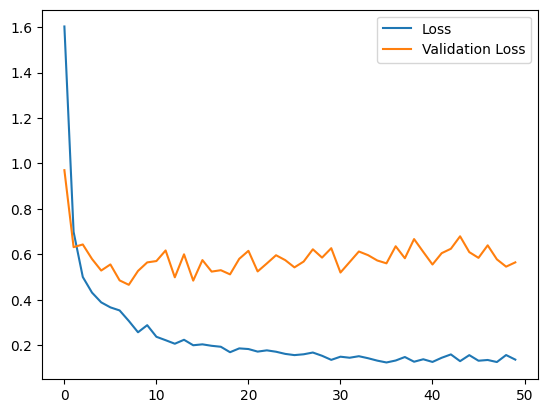

In [119]:
plt.plot(history.history["loss"], label = "Loss")
plt.plot(history.history["val_loss"], label = "Validation Loss")
plt.legend()
plt.show()